# Solving a MWIS problem with QoolQit

*Advanced Concepts used in this tutorial:*

- [Detuning Map and Detuning Map Modulator](../fundamentals/quantum_program.ipynb);

## Introduction

In this tutorial, we illustrate how to solve a Maximally Weighted Independent Set (MWIS) problem using an ensemble of Rydberg atoms in analog mode.

MWIS arises in many applications, including resource allocation, scheduling and staffing problems, error-correcting coding, complex system analysis and optimization, logistics and transportation, communication networks...

In a MWIS problem, we consider an undirected graph with nodes and edges where each node is associated with a positive weight. The problem is to find a maximum weighted independent set, i.e., select a set of nodes in graph where:
- there is no edge between any pair of selected nodes.
- the sum of the weights of the nodes for this set is maximized.

If all the weights of the nodes are the same, then this problem is called the Maximally Independent Set (MIS).

### Example of an MWIS

Suppose we are given the following graph:


It is an undirected graph with:
- 4 nodes 0, 1, 2 and 3;
- edges between nodes 0-1, 0-2, 0-3 and 3-2;
- a weight of 2 assigned to nodes 1 and 2, and a weight of 0 assigned to nodes 0 and 3.

There are two Maximally Independent Set (sets of nodes with no edge between them):
- {1, 2}: the sum of the weights of the nodes is 4.
- {1, 3}: the sum of the weights of the nodes is 2.

So **the MWIS of this graph is {1, 2}**.

/home/stefano/Workspace/qoolqit/.venv/lib/python3.14/site-packages/backoff/_decorator.py:201: DeprecationWarning: 'asyncio.iscoroutinefunction' is deprecated and slated for removal in Python 3.16; use inspect.iscoroutinefunction() instead
  if asyncio.iscoroutinefunction(target):
/home/stefano/Workspace/qoolqit/.venv/lib/python3.14/site-packages/backoff/_decorator.py:201: DeprecationWarning: 'asyncio.iscoroutinefunction' is deprecated and slated for removal in Python 3.16; use inspect.iscoroutinefunction() instead
  if asyncio.iscoroutinefunction(target):
/home/stefano/Workspace/qoolqit/.venv/lib/python3.14/site-packages/backoff/_decorator.py:201: DeprecationWarning: 'asyncio.iscoroutinefunction' is deprecated and slated for removal in Python 3.16; use inspect.iscoroutinefunction() instead
  if asyncio.iscoroutinefunction(target):


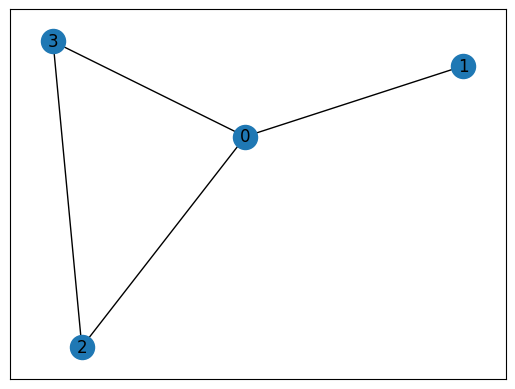

In [1]:
import numpy as np
from qoolqit import DataGraph

graph = DataGraph([(0, 1), (0, 2), (0, 3), (3, 2)])
graph.nodes[0]["weight"] = 0.0
graph.nodes[1]["weight"] = 2.0
graph.nodes[2]["weight"] = 2.0
graph.nodes[3]["weight"] = 0.0

graph.draw()

### Mathematical representation of a MWIS

Mathematically, a graph is represented by its [adjacency matrix](https://en.wikipedia.org/wiki/Adjacency_matrix) $Q$, a symmetric matrix $Q$ of size $(N \times N)$, with $N$ the number of nodes in the graph:

In [2]:
Q = np.array(
    [
        [0, 1, 1, 1],
        [1, 2, 0, 0],
        [1, 0, 2, 1],
        [1, 0, 1, 0],
    ]
)

The optimization problem associated with the MWIS is to find the bitstring $z=(z_1, \dots, z_N) \in \{0, 1 \}^N$ that maximizes the quantity
$$f(z) = \sum_i Q_{ii} z_i$$
under the constraint, for $i\ne j$, 
$$Q_{ij}z_i + Q_{ij}z_j \le 1$$

For the above graph, the optimal solution for the MWIS problem is `0110`.

**Note**:

Under the constraint $Q_{ij}\left(z_i + z_j\right) \le 1$ for $i\ne j$, the cost function $g(z) = z^T Q z$ is also a valid cost function, because:
- $g(z)= \sum_i \sum_j Q_{ij} z_i z_j$ becomes $g(z) = \sum_i Q_{ii} z_i^2$, since the condition yields that for $i\ne j$, if $Q_{ij}\ne0$ then either $z_i=0$ or $z_j=0$ (for $i\ne j$, $Q_{ij}$ is either $0$ or $1$);
- $g(z) = \sum_i Q_{ii} z_i^2 = \sum_i Q_{ii} z_i = f(z)$ because $z_i$ is either 0 or 1.

This cost function $g$ is the same as the one used when [solving a QUBO](./solving_a_qubo.ipynb), except that we want here to maximize it instead of minimizing it in the case of the QUBO.

## Solving the MWIS with `QoolQit`

Let's recall that Pulser enables you to program a [Weighted Analog Ising Hamiltonian](../extended_usage_intro.md#weighted-analog-quantum-computing) $H_Q$:

$$\frac{H_Q}{\hbar}(t) = \sum_{k=1}^N \left (\frac{\Omega(t)}{2} e^{-i\phi(t)} |g\rangle\langle r|_k + \frac{\Omega(t)}{2} e^{i\phi(t)} |r\rangle\langle g|_k - (\delta(t)\mathbf{+\epsilon_k\delta_{DMM}(t)}) |r\rangle\langle r|_k + \sum_{j<k}\frac{C_6}{\hbar R_{kj}^6} \hat{n}_k \hat{n}_j \right)
$$


The first idea is to encode the off-diagonal terms of $Q$ by using the [Rydberg interaction](../programming.md#ising-hamiltonian) between atoms: 
$$\left[\frac{C_6}{\hbar R_{kj}^6}\right]_{1\leq k, j \leq N}\leftrightarrow Q_{off-diagonal}$$

Since the Rydberg interaction depends on the pairwise distance between atoms $k$ and $j$, $R_{kj}$, this will define the `Register` of atoms to use in the computation.

<div class="alert alert-info">

**Note**:

We can make this mapping because our off-diagonal terms are positive as well.

</div>

The second idea is to encode the diagonal terms of $Q$ by using the weights of the [Detuning Map](./dmm.nblink) $\epsilon_k \leftrightarrow Q_{kk}$ for $1\le k\le N$.

Finally, the third idea is to find the optimal solution of the QUBO by preparing the ground-state of $H_Q$ and outputing the optimal bitstrings. There are multiple approaches to prepare the ground-state of an Hamiltonian, we will here use the Quantum Adiabatic Algorithm (QAA), that will define $\Omega(t)$, $\delta(t)$, $\delta_{DMM}(t)$.

### 1. Embed the graph into a Register

In [3]:
import networkx as nx
from qoolqit import Register
from qoolqit.embedding import InteractionEmbedder

# Embed the graph into a Register
A = nx.adjacency_matrix(graph, dtype=np.float64).toarray()
print("Adjacency matrix:\n", A)

embedder = InteractionEmbedder()
embedded_graph = embedder.embed(A)
register = Register.from_graph(embedded_graph)

Adjacency matrix:
 [[0. 1. 1. 1.]
 [1. 0. 0. 0.]
 [1. 0. 0. 1.]
 [1. 0. 1. 0.]]
